# Linear Regression from Scratch
In this notebook, we will implement Simple Linear Regression from scratch. We will cover the hypothesis function, the cost function, and gradient descent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load the Dataset
First, we load the dataset using `pandas`.

In [2]:
training_set = pd.read_csv("Data_SET/Salary_Data.csv")

x_train= training_set["YearsExperience"].values
y_train = training_set["Salary"].values

training_set.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


### Plotting the Training Data
This code creates a **scatter plot** to visualize the relationship between years of experience and salary.

```python
import matplotlib.pyplot as plt

# Plot the data points (X-axis: Experience, Y-axis: Salary)
plt.scatter(x_train, y_train)

# Label the axes
plt.xlabel("YearsExperience")
plt.ylabel("Salary")

# Display the plot
plt.show()

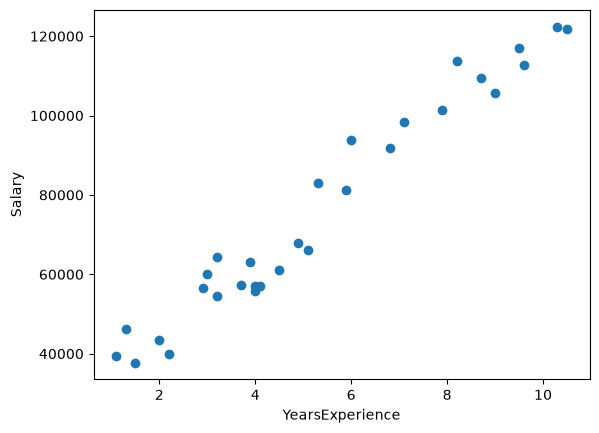

In [3]:
plt.scatter(x_train, y_train)
plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.show()

## 2. Hypothesis Function
The linear regression model is defined by the following equation:

$$
h_\theta(x) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n = X\theta
$$

## 3. Cost Function (Mean Squared Error)
The cost function $J(\theta)$ measures how well the model fits the training data. We use the Mean Squared Error (MSE):

$$
J(\theta) = \frac{1}{2m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right)^2
$$

In [4]:
def cost_function(x, y, w, b):
    m = len(x)
    cost_sum = 0

    for i in range(m):
        f = w * x[i] + b
        cost = (f - y[i]) ** 2
        cost_sum += cost

    total_cost = (1/(2*m)) * cost_sum
    return total_cost

## 4. Gradient  (Gradient Function)
The gradient function computes the partial derivatives of the cost function with respect to our parameters $w$ and $b$. These derivatives guide us on how to update our parameters to minimize the cost:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right) x^{(i)}
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{w,b}(x^{(i)}) - y^{(i)} \right)
$$

In [5]:
def gradient_function(x, y, w, b):
    m = len(x)
    dc_dw = 0
    dc_db = 0

    for i in range(m):
        f = w * x[i] + b

        dc_dw += (f - y[i]) * x[i]
        dc_db += (f - y[i])

    dc_dw = (1/m) * dc_dw
    dc_db = (1/m) * dc_db

    return dc_dw, dc_db

## 5. Gradient Descent Optimization
We update our parameters $w$ and $b$ iteratively to minimize the cost function. The update rules are:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where $\alpha$ is the learning rate.

In [6]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0

    for i in range(iterations):
        dc_dw, dc_db = gradient_function(x, y, w, b)

        w = w - alpha * dc_dw
        b = b - alpha * dc_db


    return w, b

## 6. Training the Model
We set our hyperparameters (learning rate and iterations) and run the gradient descent algorithm to find the optimal values for $w$ and $b$.

In [ ]:
learning_rate = 0.01
iterations = 10000

final_w, final_b = gradient_descent(x_train, y_train, learning_rate, iterations)

print(f"w: {final_w:.4f}, b: {final_b:.4f}")


w: 9449.9623, b: 25792.2002


## 7. Visualizing the Results
We plot the original training data points along with the trained regression line to visualize how well our model fits the data.

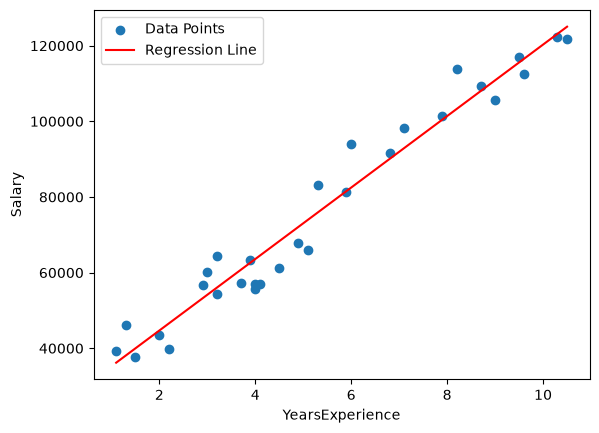

In [8]:
plt.scatter(x_train, y_train, label='Data Points')

x_vals = np.linspace(min(x_train), max(x_train), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color='red', label='Regression Line')

plt.xlabel("YearsExperience")
plt.ylabel("Salary")
plt.legend()
plt.show()